# Análise Exploratória de Dados - `happyT_A`

Este notebook realiza a etapa inicial de **Análise Exploratória de Dados (EDA)** para o conjunto `happyT_A.txt`, usado em um problema de **estimação de redshift fotométrico**. A análise busca compreender a estrutura da base, verificar sua qualidade, caracterizar distribuições e levantar evidências que orientem decisões posteriores de pré-processamento e engenharia de atributos.

As variáveis centrais do problema são:

- magnitudes fotométricas nas bandas `u`, `g`, `r`, `i`, `z`;
- erros fotométricos correspondentes `uErr`, `gErr`, `rErr`, `iErr`, `zErr`;
- alvo `redshift`;
- erro associado ao alvo `redshiftErr`, que será analisado, mas **não deve ser assumido automaticamente como atributo preditivo**, pois em um cenário real de inferência ele pode não estar disponível para novos objetos.


## 1. Carregamento dos dados

Nesta etapa, carregamos o arquivo bruto, definimos explicitamente os nomes esperados das colunas e exibimos um panorama inicial da base. Como o arquivo pode conter cabeçalhos comentados com `#`, a leitura considera esse detalhe.


In [1]:
from pathlib import Path
from io import StringIO

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")


In [19]:
data_path = Path("../data/raw/happyT_A.txt")

expected_columns = [
    "id", "u", "g", "r", "i", "z",
    "uErr", "gErr", "rErr", "iErr", "zErr",
    "redshift", "redshiftErr",
]

mag_cols = ["u", "g", "r", "i", "z"]
err_cols = ["uErr", "gErr", "rErr", "iErr", "zErr"]
target_col = "redshift"
target_err_col = "redshiftErr"

df = pd.read_csv(
    data_path,
    sep=r"\s+",
    comment="#",
    names=expected_columns,
)

print(f"Shape da base: {df.shape[0]:,} linhas x {df.shape[1]:,} colunas")
print("\nNomes das colunas lidas:")
print(df.columns.tolist())


Shape da base: 74,950 linhas x 13 colunas

Nomes das colunas lidas:
['id', 'u', 'g', 'r', 'i', 'z', 'uErr', 'gErr', 'rErr', 'iErr', 'zErr', 'redshift', 'redshiftErr']


## 2. Verificação inicial da qualidade da base

Antes de discutir distribuições ou propor transformações, é importante verificar se a base apresenta problemas estruturais que possam comprometer etapas posteriores. Aqui investigamos:

- valores nulos;
- tipos de dados;
- duplicatas gerais e duplicatas no identificador `id`;
- valores infinitos;
- valores negativos em magnitudes, erros e redshift;
- linhas com erros iguais a zero;
- quantidade de zeros em cada feature;
- observações com valores muito extremos em magnitudes e erros.

A ideia é separar o que é apenas comportamento natural do domínio astronômico daquilo que sugere ruído, baixa qualidade de medição ou necessidade de filtragem futura.


In [4]:
# Funções usadas para criar tabelas de contagem e porcentagem, e para exibir seções com títulos formatados.
def build_count_percent_table(series: pd.Series, total_rows: int, count_name: str = "count") -> pd.DataFrame: 
    summary = pd.DataFrame({count_name: series})
    summary["percent"] = 100 * summary[count_name] / total_rows
    return summary


def display_section(title: str) -> None: 
    display(Markdown(f"### {title}"))


In [5]:
# Funções usadas para criar tabelas de contagem e porcentagem, e para exibir seções com títulos formatados.
n_rows = len(df)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = mag_cols + err_cols + [target_col, target_err_col]

null_summary = build_count_percent_table(df.isna().sum(), n_rows, count_name="null_count")
dtype_summary = pd.DataFrame({"dtype": df.dtypes.astype(str)})
inf_summary = build_count_percent_table(np.isinf(df[numeric_cols]).sum(), n_rows, count_name="inf_count")

duplicate_summary = pd.DataFrame(
    {
        "count": [df.duplicated().sum(), df.duplicated(subset=["id"]).sum()],
    },
    index=["duplicated_rows", "duplicated_id"],
)
duplicate_summary["percent"] = 100 * duplicate_summary["count"] / n_rows

negative_checks = {
    "negative_magnitude_rows": (df[mag_cols] < 0).any(axis=1).sum(),
    "negative_error_rows": (df[err_cols] < 0).any(axis=1).sum(),
    "negative_redshift_rows": (df[target_col] < 0).sum(),
    "negative_redshiftErr_rows": (df[target_err_col] < 0).sum(),
}
negative_summary = build_count_percent_table(pd.Series(negative_checks), n_rows)

zero_error_checks = {
    "rows_with_any_zero_photometric_error": (df[err_cols] == 0).any(axis=1).sum(),
    "rows_with_zero_redshiftErr": (df[target_err_col] == 0).sum(),
}
zero_error_summary = build_count_percent_table(pd.Series(zero_error_checks), n_rows)
zero_feature_summary = build_count_percent_table((df[feature_cols] == 0).sum(), n_rows, count_name="zero_count")

display_section("Valores nulos por coluna")
display(null_summary)

display_section("Tipos de dados")
display(dtype_summary)

display_section("Valores infinitos por coluna numérica")
display(inf_summary)

display_section("Duplicatas")
display(duplicate_summary)

display_section("Valores negativos")
display(negative_summary)

display_section("Linhas com erros iguais a zero")
display(zero_error_summary)

display_section("Quantidade de zeros por feature")
display(zero_feature_summary.sort_values("zero_count", ascending=False))


### Valores nulos por coluna

,null_count,percent
id,0,0.000000
u,0,0.000000
g,0,0.000000
r,0,0.000000
i,0,0.000000
z,0,0.000000
uErr,0,0.000000
gErr,0,0.000000
rErr,0,0.000000
iErr,0,0.000000


### Tipos de dados

,dtype
id,int64
u,float64
g,float64
r,float64
i,float64
z,float64
uErr,float64
gErr,float64
rErr,float64
iErr,float64


### Valores infinitos por coluna numérica

...

,count,percent
negative_magnitude_rows,0,0.000000
negative_error_rows,0,0.000000
negative_redshift_rows,0,0.000000
negative_redshiftErr_rows,0,0.000000


### Linhas com erros iguais a zero

,count,percent
rows_with_any_zero_photometric_error,0,0.000000
rows_with_zero_redshiftErr,0,0.000000


### Quantidade de zeros por feature

,zero_count,percent
u,0,0.000000
g,0,0.000000
r,0,0.000000
i,0,0.000000
z,0,0.000000
uErr,0,0.000000
gErr,0,0.000000
rErr,0,0.000000
iErr,0,0.000000
zErr,0,0.000000


Valor extremo é uma observação que se encontra muito distante da faixa central da distribuição de uma variável. Nesta análise, um valor foi considerado extremo quando ficou abaixo de Q1 - 1.5 * IQR ou acima de Q3 + 1.5 * IQR, onde Q1 e Q3 são os quartis de 25% e 75%, e IQR = Q3 - Q1. Isso não implica necessariamente erro de medição, mas sinaliza observações atípicas que merecem investigação, especialmente por poderem representar baixa qualidade fotométrica, caudas longas na distribuição ou casos raros relevantes para a modelagem.

In [6]:
extreme_cols = mag_cols + err_cols
q1 = df[extreme_cols].quantile(0.25)
q3 = df[extreme_cols].quantile(0.75)
iqr = q3 - q1
lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr

extreme_summary = pd.DataFrame(index=extreme_cols)
extreme_summary["lower_fence"] = lower_fence
extreme_summary["upper_fence"] = upper_fence
extreme_summary["below_lower_fence"] = [int((df[col] < lower_fence[col]).sum()) for col in extreme_cols]
extreme_summary["above_upper_fence"] = [int((df[col] > upper_fence[col]).sum()) for col in extreme_cols]
extreme_summary["total_extreme"] = extreme_summary["below_lower_fence"] + extreme_summary["above_upper_fence"]
extreme_summary["percent_extreme"] = 100 * extreme_summary["total_extreme"] / n_rows

rows_with_extreme_mag = ((df[mag_cols] < lower_fence[mag_cols]) | (df[mag_cols] > upper_fence[mag_cols])).any(axis=1).sum()
rows_with_extreme_err = ((df[err_cols] < lower_fence[err_cols]) | (df[err_cols] > upper_fence[err_cols])).any(axis=1).sum()

row_extreme_summary = build_count_percent_table(
    pd.Series(
        {
            "rows_with_extreme_magnitudes": rows_with_extreme_mag,
            "rows_with_extreme_errors": rows_with_extreme_err,
        }
    ),
    n_rows,
)

display_section("Resumo de valores muito extremos via regra do IQR")
display(extreme_summary.sort_values("percent_extreme", ascending=False))

display_section("Linhas com ao menos um valor extremo")
display(row_extreme_summary)


### Resumo de valores muito extremos via regra do IQR

,lower_fence,upper_fence,below_lower_fence,above_upper_fence,total_extreme,percent_extreme
zErr,0.009640,0.247265,0,3253,3253,4.340227
gErr,-0.164723,0.378368,0,2591,2591,3.456971
iErr,0.009394,0.166107,0,2475,2475,3.302201
rErr,-0.039675,0.211843,0,1627,1627,2.170781
uErr,-0.946873,1.792884,0,929,929,1.239493
z,13.345702,22.422200,183,97,280,0.373582
i,13.411712,23.084927,133,29,162,0.216144
r,13.048654,24.788925,41,7,48,0.064043
g,12.905070,27.351349,10,1,11,0.014676
u,14.294491,29.576532,9,2,11,0.014676


### Linhas com ao menos um valor extremo

,count,percent
rows_with_extreme_magnitudes,304,0.405604
rows_with_extreme_errors,6700,8.939293


### Leituras iniciais da qualidade da base

A inspeção inicial indica que a base apresenta boa qualidade estrutural para utilização em modelos de aprendizado de máquina. Não foram identificados valores nulos, infinitos ou registros duplicados, tanto considerando as linhas completas quanto o identificador dos objetos. Além disso, todas as variáveis foram carregadas em formatos numéricos adequados (`float64` para atributos contínuos e `int64` para o identificador), não sendo necessárias conversões de tipo nesta etapa.

Também não foram encontrados valores fisicamente inconsistentes, como magnitudes negativas, erros fotométricos negativos, redshifts negativos ou incertezas de redshift iguais a zero. A contagem de zeros por feature complementa esse diagnóstico ao mostrar em quais variáveis esse valor aparece e com que frequência, distinguindo casos estruturalmente aceitáveis de possíveis sinais de baixa variabilidade ou necessidade de atenção futura.

A análise de valores extremos utilizando a regra do IQR mostrou comportamentos distintos entre magnitudes e erros fotométricos. As magnitudes apresentam uma quantidade muito pequena de observações classificadas como extremas, representando menos de 0,5% da base. Em contrapartida, os erros fotométricos concentram uma parcela significativamente maior de valores acima do limite superior do IQR, especialmente nas bandas z, g e i.

No total, apenas 304 objetos (0,41%) possuem pelo menos uma magnitude extrema, enquanto 6.700 objetos (8,94%) apresentam ao menos um erro fotométrico extremo. Como erros elevados estão frequentemente associados a observações de menor qualidade ou menor relação sinal-ruído, esses registros não devem ser tratados automaticamente como erros de coleta. Pelo contrário, podem representar uma fonte relevante de informação para a investigação proposta, que busca avaliar o impacto das incertezas fotométricas na estimativa de redshift.


## 3. Estatisticas descritivas gerais

Nesta etapa, vamos analisar as escalas das features preditivas e suas diferencas. A tabela abaixo mantem apenas medidas uteis para identificar diferencas grandes de escala entre variaveis: mediana, IQR, p95, maximo e razoes relativas a menor escala observada. Em seguida, os histogramas e boxplots ajudam a entender a forma das distribuicoes e suas caudas.


### Escalas


In [21]:
display(df.head())
display(df.drop(columns=["id"]).describe(include="all"))

,id,u,g,r,i,z,uErr,gErr,rErr,iErr,zErr,redshift,redshiftErr
0,1237645879562928805,25.155375,22.232981,21.257841,19.889854,19.427107,1.034657,0.219033,0.206952,0.147347,0.228686,0.752707,0.000287
1,1237645942905504040,21.910667,19.464439,18.372978,17.955502,17.642979,0.443852,0.060666,0.064809,0.069981,0.096798,0.164360,0.000066
2,1237645942905635180,20.978670,20.276821,19.472305,19.232706,18.994177,0.150120,0.070810,0.076891,0.085570,0.132459,0.326150,0.000011
3,1237645942906224860,20.389980,19.313643,17.891615,17.415066,17.181231,0.331636,0.113295,0.092397,0.093178,0.127449,0.274926,0.000063
4,1237645943978721520,23.907169,23.448675,20.256517,19.163860,18.557152,1.527960,1.033415,0.177488,0.132869,0.149485,0.592983,0.000148


,u,g,r,i,z,uErr,gErr,rErr,iErr,zErr,redshift,redshiftErr
count,"74,950.000000","74,950.000000","74,950.000000","74,950.000000","74,950.000000","74,950.000000","74,950.000000","74,950.000000","74,950.000000","74,950.000000","74,950.000000","74,950.000000"
mean,22.088931,20.236337,18.911176,18.224478,17.865348,0.489029,0.129200,0.093469,0.094140,0.140991,0.350706,0.000212
std,2.358682,2.023045,1.679568,1.450241,1.406706,0.457213,0.196016,0.100895,0.098290,0.121952,0.210272,0.014277
min,11.670498,10.543657,10.713271,10.601875,10.677568,0.011919,0.022127,0.034476,0.040540,0.047619,0.000006,0.000003
25%,20.025256,18.322425,17.451256,17.039167,16.749389,0.080535,0.038936,0.054644,0.068161,0.098749,0.135274,0.000025
50%,22.349543,20.870521,19.229371,18.552001,18.160522,0.383301,0.093428,0.078035,0.084909,0.123817,0.374342,0.000076
75%,23.845766,21.933994,20.386323,19.457471,19.018513,0.765475,0.174709,0.117524,0.107340,0.158156,0.529428,0.000140
max,31.474758,28.651567,27.929350,28.221367,29.105049,11.780122,32.901323,8.897392,13.247561,9.394168,1.471981,2.779110


As estatísticas descritivas indicam diferenças significativas de escala entre os grupos de atributos. As magnitudes fotométricas (u, g, r, i e z) apresentam médias entre aproximadamente 18 e 22, enquanto os erros fotométricos possuem médias inferiores a 0,5. O redshift, por sua vez, apresenta média de 0,35, situando-se em uma escala mais próxima dos erros do que das magnitudes. Essas diferenças podem influenciar modelos sensíveis à escala dos dados, como regressões, redes neurais e métodos baseados em distância, tornando a padronização das variáveis uma etapa relevante a ser investigada durante o pré-processamento. Além disso, observa-se que o erro da banda u possui magnitude consideravelmente superior aos demais erros fotométricos, sugerindo uma maior variabilidade nas medições dessa banda.

### Distribuições

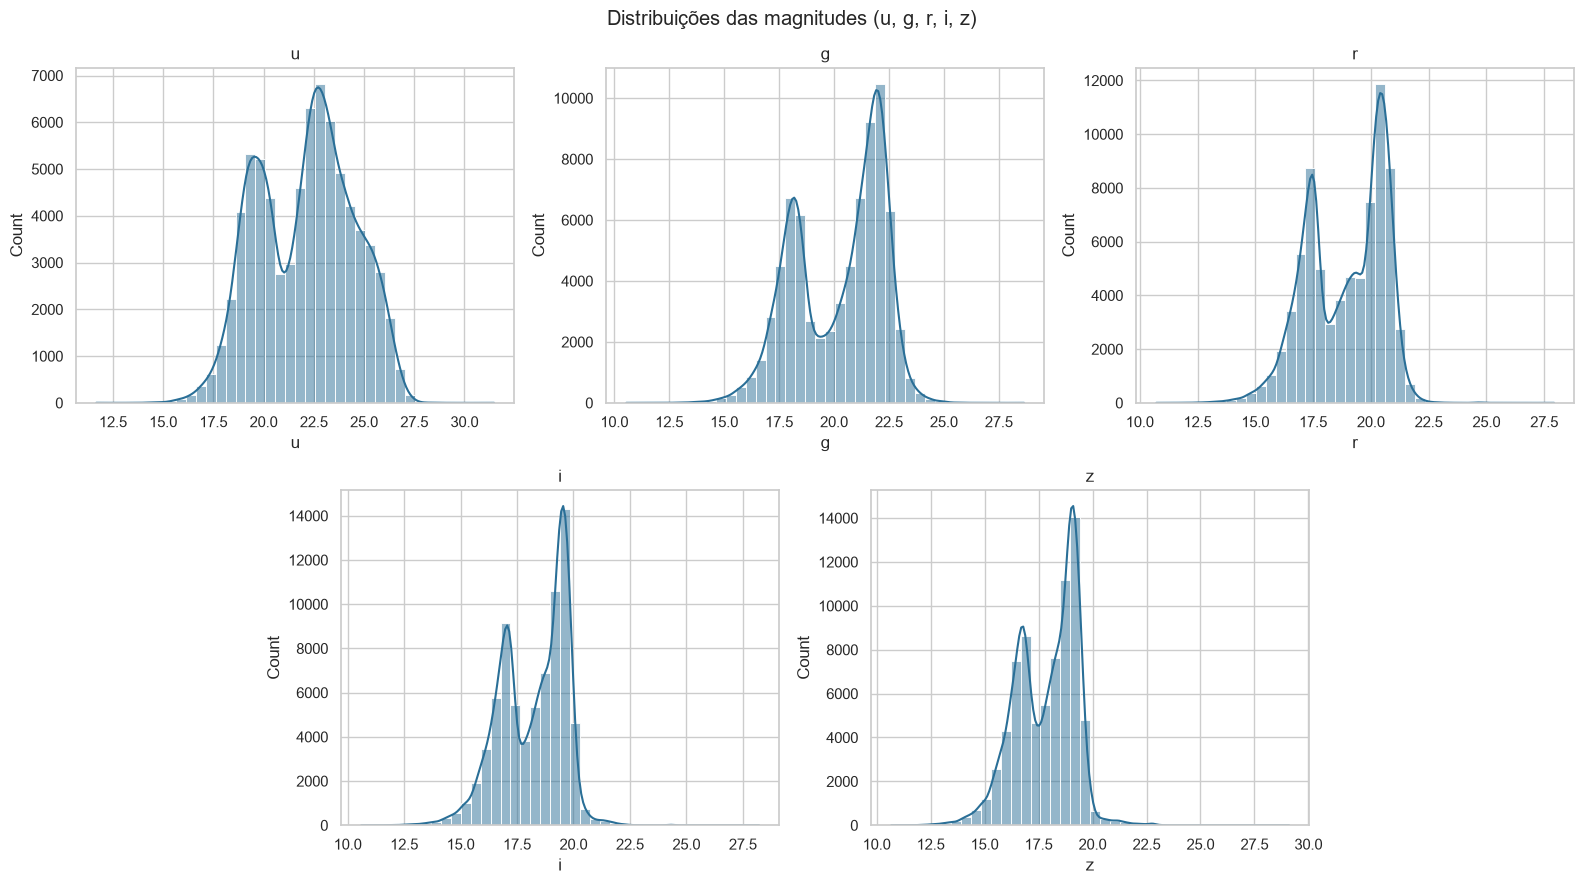

In [7]:
analysis_cols = mag_cols + err_cols + [target_col, target_err_col]
    
fig = plt.figure(figsize=(16, 9))
grid = fig.add_gridspec(2, 6)
axes = [
    fig.add_subplot(grid[0, 0:2]),
    fig.add_subplot(grid[0, 2:4]),
    fig.add_subplot(grid[0, 4:6]),
    fig.add_subplot(grid[1, 1:3]),
    fig.add_subplot(grid[1, 3:5]),
]

for ax, col in zip(axes, mag_cols):
    sns.histplot(df[col], bins=40, kde=True, ax=ax, color="#2a6f97")
    ax.set_title(col)

plt.suptitle("Distribuições das magnitudes (u, g, r, i, z)", y=0.98)
plt.tight_layout()
plt.show()


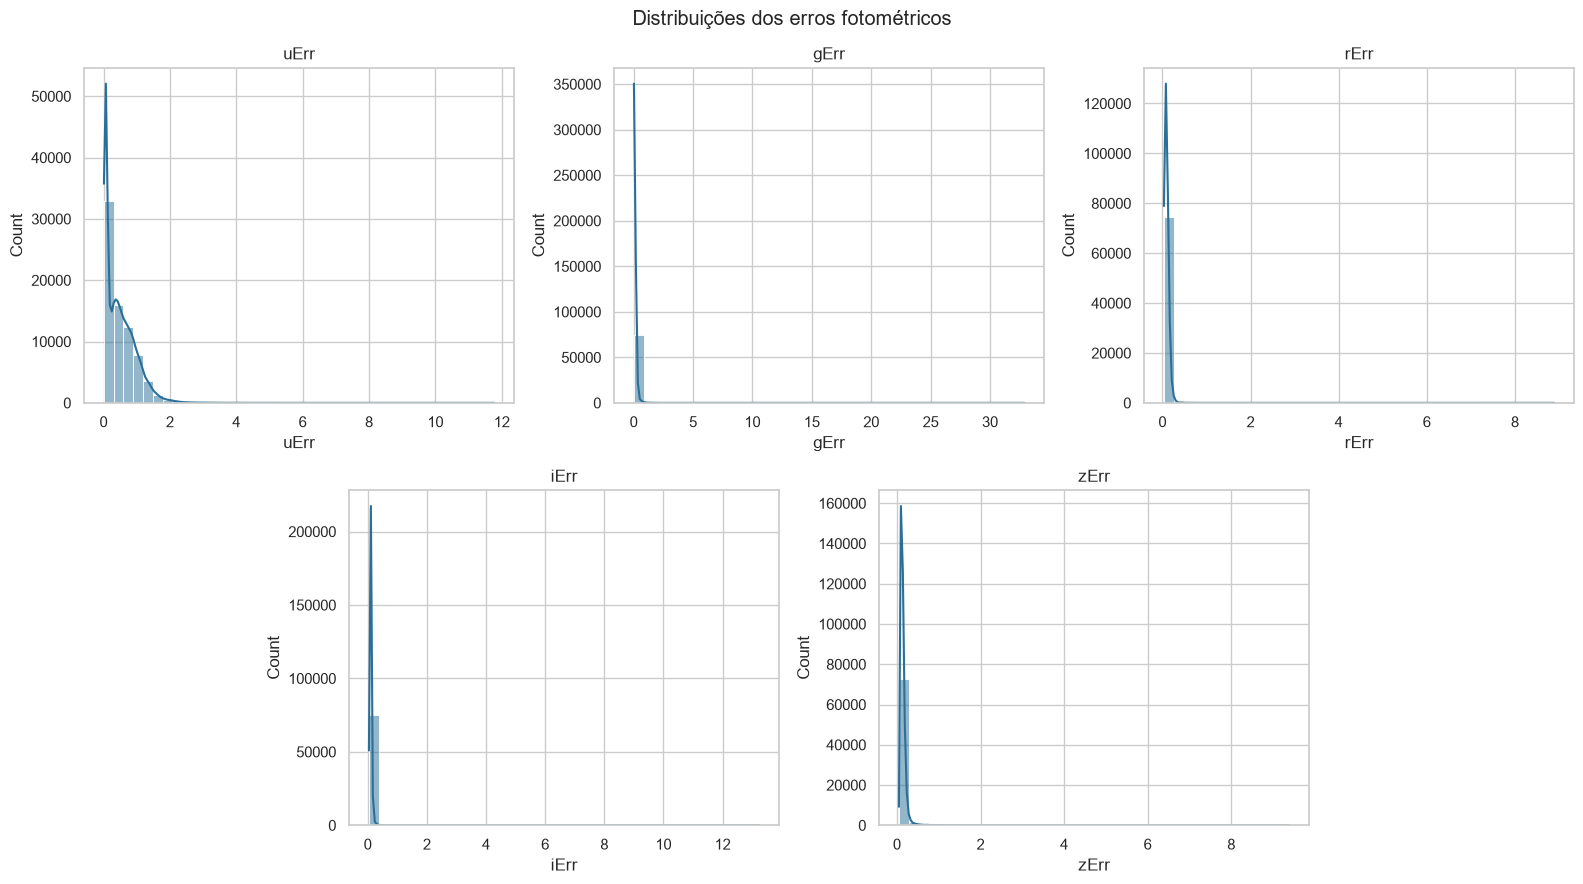

In [8]:
fig = plt.figure(figsize=(16, 9))
grid = fig.add_gridspec(2, 6)
axes = [
    fig.add_subplot(grid[0, 0:2]),
    fig.add_subplot(grid[0, 2:4]),
    fig.add_subplot(grid[0, 4:6]),
    fig.add_subplot(grid[1, 1:3]),
    fig.add_subplot(grid[1, 3:5]),
]

for ax, col in zip(axes, err_cols):
    sns.histplot(df[col], bins=40, kde=True, ax=ax, color="#2a6f97")
    ax.set_title(col)

plt.suptitle("Distribuições dos erros fotométricos", y=0.98)
plt.tight_layout()
plt.show()


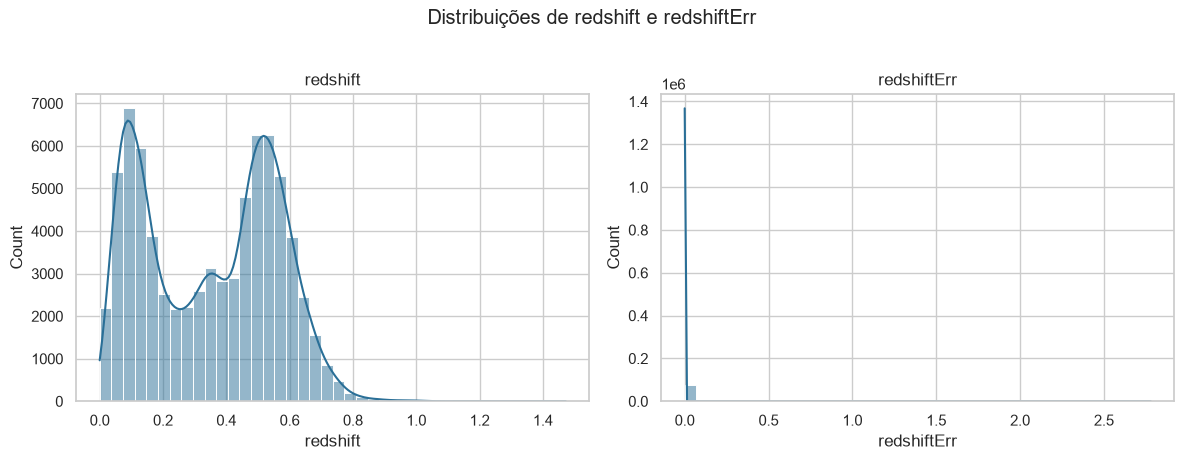

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, col in zip(axes, [target_col, target_err_col]):
    sns.histplot(df[col], bins=40, kde=True, ax=ax, color="#2a6f97")
    ax.set_title(col)

plt.suptitle("Distribuições de redshift e redshiftErr", y=1.02)
plt.tight_layout()
plt.show()


Para mostrar a assimetria de `redshiftErr` mais claramente, vamos dar um "zoom"... 

Text(0.5, 1.0, 'Distribuições de redshiftErr com zoom (quartil 0.99)')

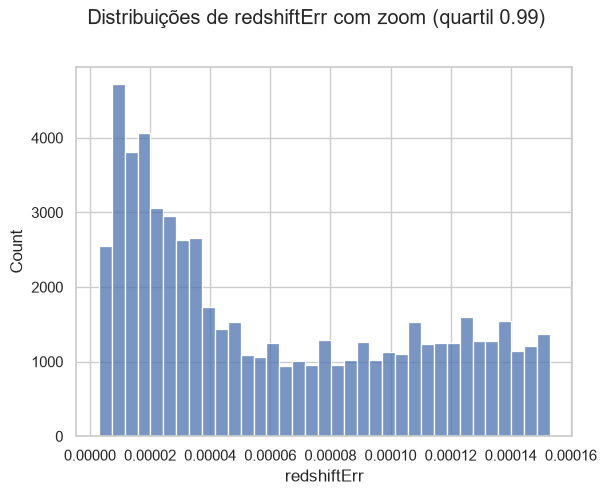

In [16]:
sns.histplot(
    df.loc[df["redshiftErr"] < df["redshiftErr"].quantile(0.80),
           "redshiftErr"]
)
plt.suptitle("Distribuições de redshiftErr com zoom (quartil 0.99)", y=1.0)


Distribuições univariadas das variáveis

Os histogramas revelam comportamentos bastante distintos entre as magnitudes, os erros fotométricos e as variáveis associadas ao redshift.

As magnitudes das bandas **u, g, r, i e z** apresentam distribuições concentradas em faixas relativamente estreitas e com indícios de multimodalidade, sugerindo a presença de diferentes populações de objetos observados. Embora existam algumas observações extremas identificadas anteriormente, a maior parte dos dados encontra-se distribuída em regiões bem definidas, sem evidências de caudas excessivamente longas.

Os **erros fotométricos** exibem um comportamento diferente. Todas as bandas apresentam forte assimetria à direita, com grande concentração de observações próximas de valores baixos e uma cauda que se estende para valores mais elevados. Esse padrão é compatível com a expectativa física de que a maioria dos objetos possua medições relativamente precisas, enquanto uma parcela menor apresenta observações mais incertas. Esse resultado ajuda a explicar a quantidade relativamente elevada de valores classificados como extremos pela regra do IQR observada na etapa anterior.

A variável **redshift** também apresenta uma distribuição não unimodal, com regiões de maior concentração em determinados intervalos e menor densidade em outros e assimétrica a direita. Isso sugere que certos intervalos de redshift estão mais representados no catálogo do que outros, característica que pode influenciar o desempenho dos modelos ao longo das diferentes faixas de distância cosmológica.

Por fim, a variável **redshiftErr** encontra-se fortemente concentrada próxima de zero e assimétrica a direita, indicando que a grande maioria das medições espectroscópicas utilizadas como referência possui incertezas muito pequenas. Isso é desejável para a tarefa estudada, uma vez que reduz a contribuição do erro da variável alvo e permite avaliar de forma mais direta o impacto das incertezas fotométricas presentes nas variáveis de entrada.

### Boxplots

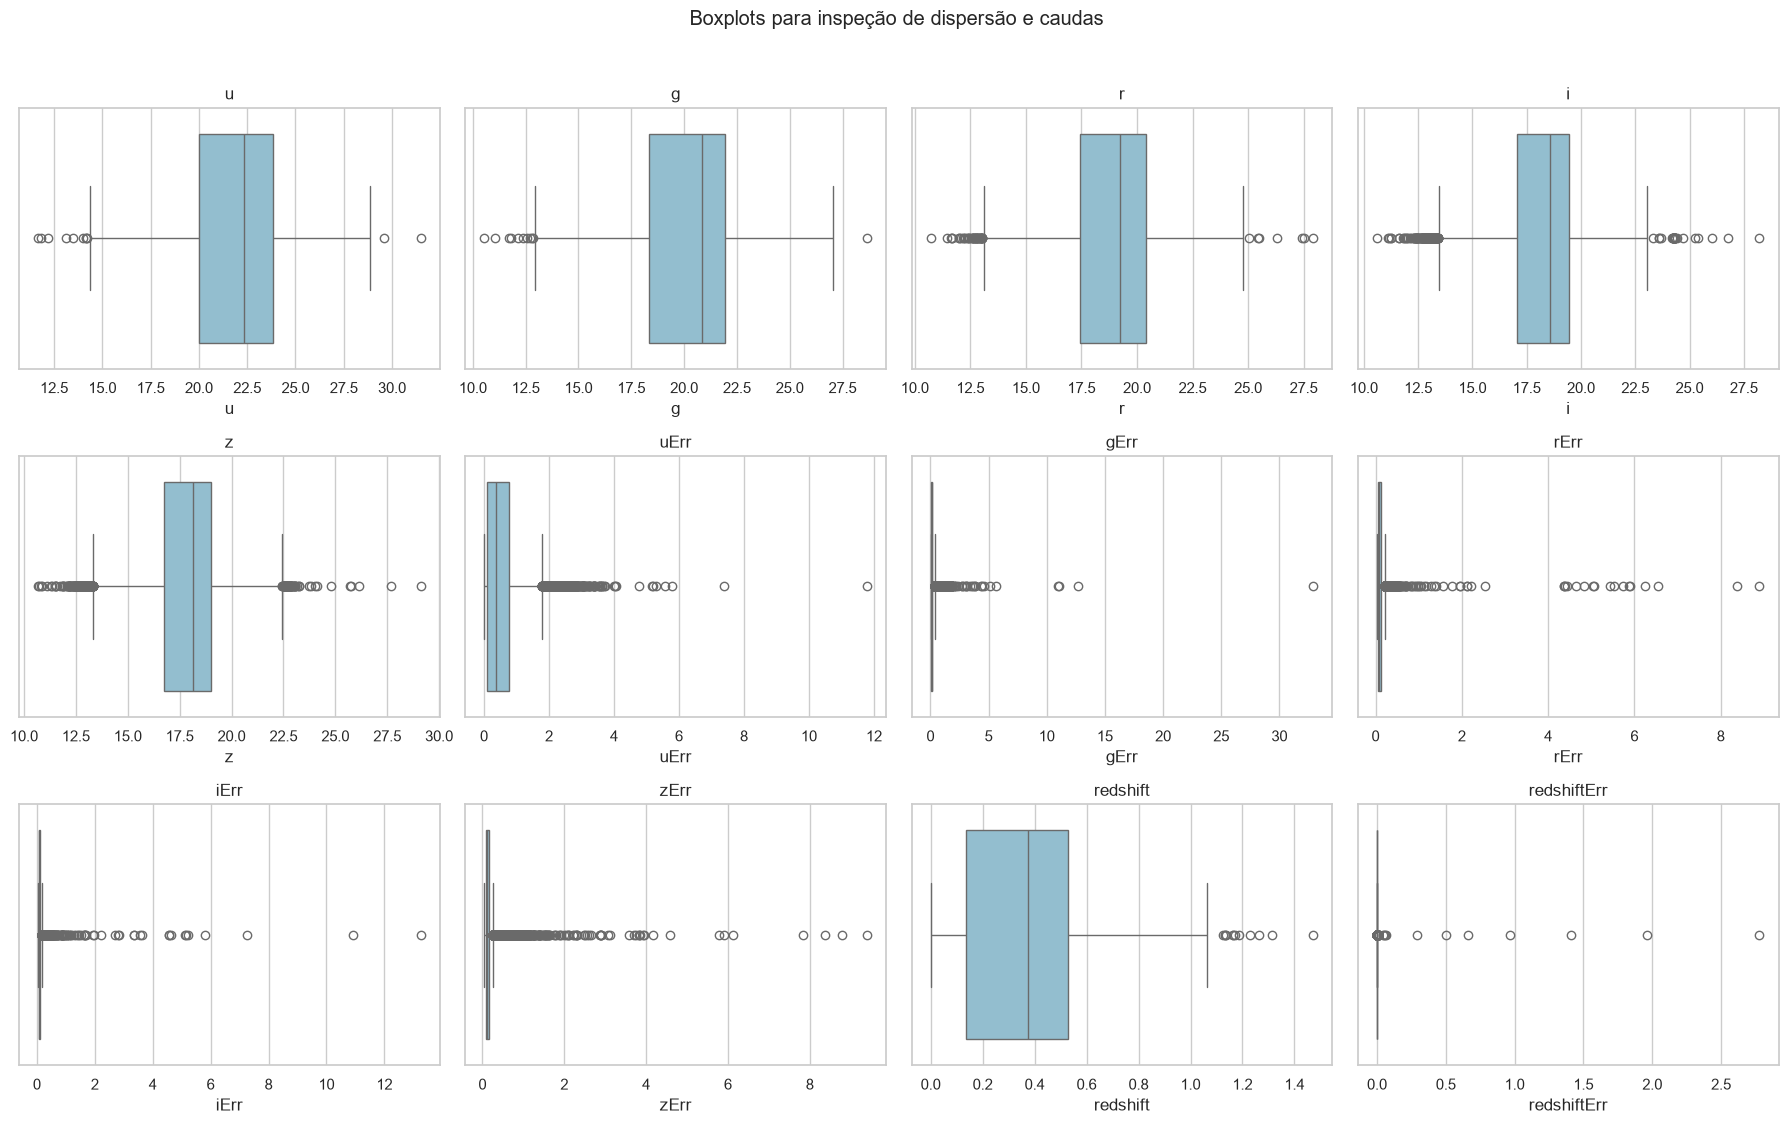

In [11]:
fig, axes = plt.subplots(3, 4, figsize=(18, 11))
axes = axes.flatten()

for ax, col in zip(axes, analysis_cols):
    sns.boxplot(x=df[col], ax=ax, color="#89c2d9")
    ax.set_title(col)

for ax in axes[len(analysis_cols):]:
    ax.axis("off")

plt.suptitle("Boxplots para inspeção de dispersão e caudas", y=1.02)
plt.tight_layout()
plt.show()


Os boxplots reforçam as observações obtidas nos histogramas e permitem visualizar com maior clareza a dispersão dos dados, a presença de observações extremas e possíveis assimetrias nas distribuições.

As magnitudes (**u, g, r, i e z**) apresentam dispersões relativamente controladas e uma quantidade reduzida de outliers quando comparadas ao tamanho da amostra. Embora existam observações classificadas como extremas em ambas as extremidades, elas representam uma pequena fração dos dados e não sugerem problemas evidentes de qualidade.

Os erros fotométricos (**uErr, gErr, rErr, iErr e zErr**) exibem um comportamento distinto. A maior parte das observações encontra-se concentrada próxima de valores baixos, enquanto um conjunto menor de registros se estende para valores significativamente maiores. Esse padrão resulta em distribuições fortemente assimétricas à direita e explica a elevada quantidade de outliers identificados pela regra do IQR. Como essas variáveis representam incertezas observacionais, valores elevados não devem ser interpretados automaticamente como erros de coleta, podendo refletir objetos observados com menor precisão.

A variável **redshift** apresenta dispersão moderada e uma leve assimetria positiva, com predominância de objetos em baixos redshifts e uma quantidade menor de observações em regiões mais distantes.

Já a variável **redshiftErr** encontra-se fortemente concentrada próxima de zero. Embora o histograma sugira uma distribuição extremamente concentrada, o boxplot revela a existência de alguns valores significativamente maiores, caracterizando uma distribuição assimétrica à direita. Nesse caso, a aparente ausência de uma cauda longa no histograma decorre da grande concentração de observações próximas de zero, que comprime visualmente a maior parte da distribuição. Como a mediana é substancialmente menor que a média, observa-se que poucos valores mais elevados exercem influência relevante sobre as medidas de tendência central.

De forma geral, os resultados indicam que os principais desafios de pré-processamento estão relacionados às distribuições assimétricas dos erros fotométricos, diferenças de escalas entre features e à interpretação de observações com elevada incerteza, e não à presença de inconsistências estruturais na base.

## 4. Analise do alvo redshift

Nesta secao, vamos explorar o alvo `redshift` com mais cuidado. O objetivo e entender a forma da distribuicao, verificar se ha assimetria e medir se o dataset tem poucos exemplos em redshifts altos.


### Distribuicao e dispersao do alvo

O histograma mostra onde os objetos se concentram ao longo do redshift. O boxplot complementa a leitura ao destacar a mediana, a dispersao central e possiveis valores extremos na cauda direita.


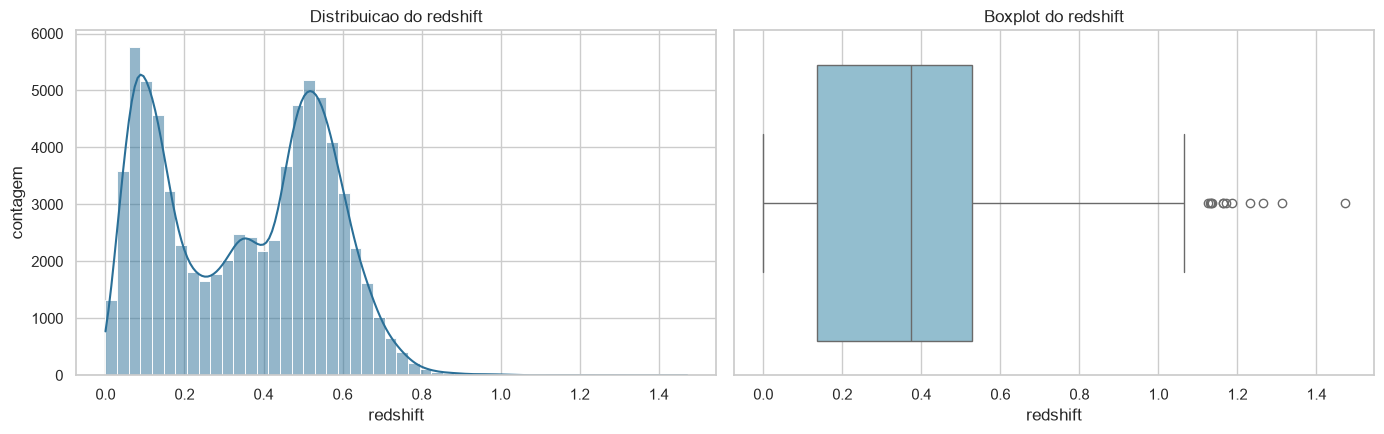

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sns.histplot(df[target_col], bins=50, kde=True, ax=axes[0], color="#2a6f97")
axes[0].set_title("Distribuicao do redshift")
axes[0].set_xlabel("redshift")
axes[0].set_ylabel("contagem")

sns.boxplot(x=df[target_col], ax=axes[1], color="#89c2d9")
axes[1].set_title("Boxplot do redshift")
axes[1].set_xlabel("redshift")

plt.tight_layout()
plt.show()


### Estatisticas por quantis

Os quantis ajudam a localizar a massa da distribuicao sem depender apenas da media. Aqui observamos desde os valores minimos ate a cauda alta do `redshift`.


In [24]:
redshift_quantiles = pd.DataFrame({
    "quantil": ["min", "p01", "p05", "p10", "p25", "p50", "p75", "p90", "p95", "p99", "max"],
    "redshift": df[target_col].quantile([0, 0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 1]).to_numpy(),
})

display(redshift_quantiles.style.format({"redshift": "{:.6f}"}))


,quantil,redshift
0,min,0.000006
1,p01,0.023621
2,p05,0.050679
3,p10,0.073093
4,p25,0.135274
5,p50,0.374342
6,p75,0.529428
7,p90,0.607613
8,p95,0.655668
9,p99,0.748362


### Contagem de objetos por faixa de redshift

Agora agrupamos o alvo em faixas fixas de redshift. Essa tabela e util para identificar desbalanceamento: se uma faixa tiver poucos objetos, o modelo tera menos exemplos para aprender padroes naquela regiao.


In [25]:
redshift_bins = [0.0, 0.1, 0.2, 0.3, 0.5, 0.7, np.inf]
redshift_bin_labels = [
    "0.0 a 0.1",
    "0.1 a 0.2",
    "0.2 a 0.3",
    "0.3 a 0.5",
    "0.5 a 0.7",
    "acima de 0.7",
]

redshift_bin_series = pd.cut(
    df[target_col],
    bins=redshift_bins,
    labels=redshift_bin_labels,
    right=False,
    include_lowest=True,
)

redshift_bin_summary = (
    redshift_bin_series
    .value_counts(sort=False)
    .rename_axis("faixa_redshift")
    .reset_index(name="frequencia_absoluta")
)
redshift_bin_summary["percentual"] = 100 * redshift_bin_summary["frequencia_absoluta"] / len(df)
redshift_bin_summary["percentual_acumulado"] = redshift_bin_summary["percentual"].cumsum()

display(redshift_bin_summary.style.format({
    "frequencia_absoluta": "{:,}",
    "percentual": "{:.2f}%",
    "percentual_acumulado": "{:.2f}%",
}))


,faixa_redshift,frequencia_absoluta,percentual,percentual_acumulado
0,0.0 a 0.1,"12,716",16.97%,16.97%
1,0.1 a 0.2,"12,800",17.08%,34.04%
2,0.2 a 0.3,"6,064",8.09%,42.13%
3,0.3 a 0.5,"19,435",25.93%,68.07%
4,0.5 a 0.7,"22,147",29.55%,97.61%
5,acima de 0.7,"1,788",2.39%,100.00%


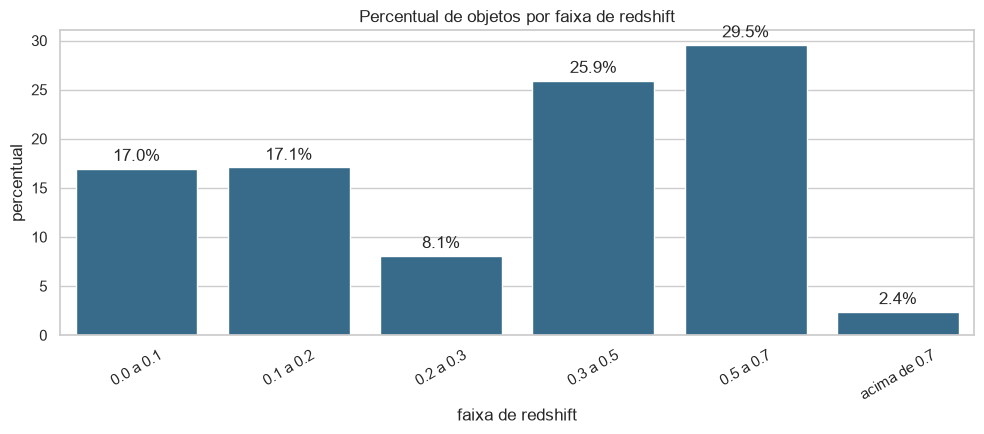

In [26]:
fig, ax = plt.subplots(figsize=(10, 4.5))

sns.barplot(
    data=redshift_bin_summary,
    x="faixa_redshift",
    y="percentual",
    ax=ax,
    color="#2a6f97",
)

ax.set_title("Percentual de objetos por faixa de redshift")
ax.set_xlabel("faixa de redshift")
ax.set_ylabel("percentual")
ax.tick_params(axis="x", rotation=30)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.tight_layout()
plt.show()


### Leitura da distribuicao do alvo

A tabela por faixas permite avaliar diretamente se o dataset esta desbalanceado em `redshift`. Em especial, a faixa `acima de 0.7` deve ser observada com cuidado, pois poucos exemplos nessa regiao podem fazer com que o modelo tenha desempenho pior justamente em objetos de redshift mais alto.

Nas proximas etapas de modelagem, vale acompanhar metricas globais e tambem metricas separadas por faixa de `redshift`, para evitar que uma boa media geral esconda erros maiores nos redshifts menos representados.


### Análise da distribuição do alvo (`redshift`)

A variável alvo `redshift` não apresenta uma distribuição uniforme. Observa-se uma concentração maior de objetos em redshifts baixos e médios, especialmente entre `0.3` e `0.7`. A distribuição também apresenta comportamento multimodal, com picos visíveis próximos de `0.1` e `0.5`.

Pelas faixas analisadas, a maior parte dos objetos está concentrada entre `0.3` e `0.7`:

- `0.0 a 0.1`: 16.97%
- `0.1 a 0.2`: 17.08%
- `0.2 a 0.3`: 8.09%
- `0.3 a 0.5`: 25.93%
- `0.5 a 0.7`: 29.55%
- `acima de 0.7`: 2.39%

Isso indica um desbalanceamento **na distribuição** do alvo: algumas regiões de redshift possuem muito mais exemplos do que outras. Em especial, há poucos objetos com `redshift > 0.7`, o que pode dificultar o aprendizado do modelo nessa faixa.

O boxplot também mostra uma cauda à direita, com alguns valores mais altos chegando até aproximadamente `1.47`. Porém, pelos quantis, 99% dos objetos possuem `redshift` abaixo de `0.748`, mostrando que esses valores altos são raros.

Essa distribuição tem implicações importantes para a modelagem. O modelo pode apresentar bom desempenho global por acertar melhor as regiões mais frequentes, mas ainda assim errar mais nas faixas menos representadas. Por isso, além de métricas globais como MAE e RMSE, é recomendável avaliar o erro por faixas de redshift.

## 5. Analise dos Erros das Magnitudes

Nesta secao, investigamos as colunas de erro fotometrico `uErr`, `gErr`, `rErr`, `iErr` e `zErr`. O objetivo nao e apenas detectar outliers, mas avaliar se essas incertezas carregam informacao relevante para a estimativa de `redshift`.

Erros maiores indicam menor confianca na magnitude observada. Em um problema de redshift fotometrico, isso pode ser informativo: objetos com medidas mais incertas podem ter relacoes menos estaveis entre cores, magnitudes e redshift. Por isso, as incertezas fotometricas podem ser candidatas importantes a features em modelos de Machine Learning.


### 5.1 Estatisticas descritivas dos erros

A tabela abaixo resume a escala, a dispersao, a assimetria e a presenca de valores extremos nas colunas de erro. Alem das estatisticas usuais, incluimos percentuais acima de limiares fixos (`0.1`, `0.2`, `0.5` e `1.0`) para comparar diretamente a frequencia de erros altos entre as bandas.


In [31]:
error_thresholds = [0.1, 0.2, 0.5, 1.0]

error_stats = pd.DataFrame(index=err_cols)
error_stats["count"] = df[err_cols].count()
error_stats["mean"] = df[err_cols].mean()
error_stats["std"] = df[err_cols].std()
error_stats["min"] = df[err_cols].min()
error_stats["p1"] = df[err_cols].quantile(0.01)
error_stats["p5"] = df[err_cols].quantile(0.05)
error_stats["p25"] = df[err_cols].quantile(0.25)
error_stats["median"] = df[err_cols].median()
error_stats["p75"] = df[err_cols].quantile(0.75)
error_stats["p90"] = df[err_cols].quantile(0.90)
error_stats["p95"] = df[err_cols].quantile(0.95)
error_stats["p99"] = df[err_cols].quantile(0.99)
error_stats["max"] = df[err_cols].max()
error_stats["skewness"] = df[err_cols].skew()
error_stats["kurtosis"] = df[err_cols].kurtosis()
error_stats["zeros"] = (df[err_cols] == 0).sum()
error_stats["negative_values"] = (df[err_cols] < 0).sum()

for threshold in error_thresholds:
    error_stats[f"pct_above_{threshold}"] = 100 * (df[err_cols] > threshold).mean()

display(error_stats.style.format({
    "count": "{:,}",
    "mean": "{:.6f}",
    "std": "{:.6f}",
    "min": "{:.6f}",
    "p1": "{:.6f}",
    "p5": "{:.6f}",
    "p25": "{:.6f}",
    "median": "{:.6f}",
    "p75": "{:.6f}",
    "p90": "{:.6f}",
    "p95": "{:.6f}",
    "p99": "{:.6f}",
    "max": "{:.6f}",
    "skewness": "{:.3f}",
    "kurtosis": "{:.3f}",
    "zeros": "{:,}",
    "negative_values": "{:,}",
    "pct_above_0.1": "{:.2f}%",
    "pct_above_0.2": "{:.2f}%",
    "pct_above_0.5": "{:.2f}%",
    "pct_above_1.0": "{:.2f}%",
}))


,count,mean,std,min,p1,p5,p25,median,p75,p90,p95,p99,max,skewness,kurtosis,zeros,negative_values,pct_above_0.1,pct_above_0.2,pct_above_0.5,pct_above_1.0
uErr,"74,950",0.489029,0.457213,0.011919,0.023169,0.034318,0.080535,0.383301,0.765475,1.108304,1.336337,1.874751,11.780122,1.534,8.496,0,0,71.00%,63.19%,41.32%,13.77%
gErr,"74,950",0.129200,0.196016,0.022127,0.026338,0.029226,0.038936,0.093428,0.174709,0.256046,0.333226,0.613200,32.901323,73.011,10941.903,0,0,48.08%,18.73%,1.61%,0.24%
rErr,"74,950",0.093469,0.100895,0.034476,0.040500,0.044275,0.054644,0.078035,0.117524,0.154132,0.179345,0.246826,8.897392,45.245,2889.326,0,0,35.83%,2.89%,0.09%,0.04%
iErr,"74,950",0.094140,0.098290,0.040540,0.050764,0.055832,0.068161,0.084909,0.107340,0.132692,0.152337,0.215270,13.247561,70.923,7329.124,0,0,31.99%,1.40%,0.10%,0.05%
zErr,"74,950",0.140991,0.121952,0.047619,0.065402,0.075770,0.098749,0.123817,0.158156,0.200956,0.238132,0.422914,9.394168,30.439,1657.104,0,0,73.66%,10.20%,0.72%,0.16%


A leitura principal desta tabela deve comparar as bandas entre si. Uma banda com media, mediana, p95 ou percentual acima dos limiares muito maior que as demais pode indicar uma regiao fotometrica mais ruidosa. Skewness e kurtosis altos sugerem caudas longas e concentracao de poucos valores extremos.

Esses padroes nao devem ser interpretados automaticamente como erro de coleta. Como os erros representam incerteza observacional, valores altos podem carregar informacao real sobre a confiabilidade da medida e, portanto, sobre a dificuldade de estimar `redshift` para certos objetos.


### 5.2 Distribuicao dos erros por banda

Agora visualizamos a distribuicao dos erros por banda. Os histogramas em escala original ajudam a enxergar a concentracao dos valores, os histogramas com `np.log1p` reduzem o efeito visual das caudas longas, e os boxplots destacam dispersao e outliers extremos.


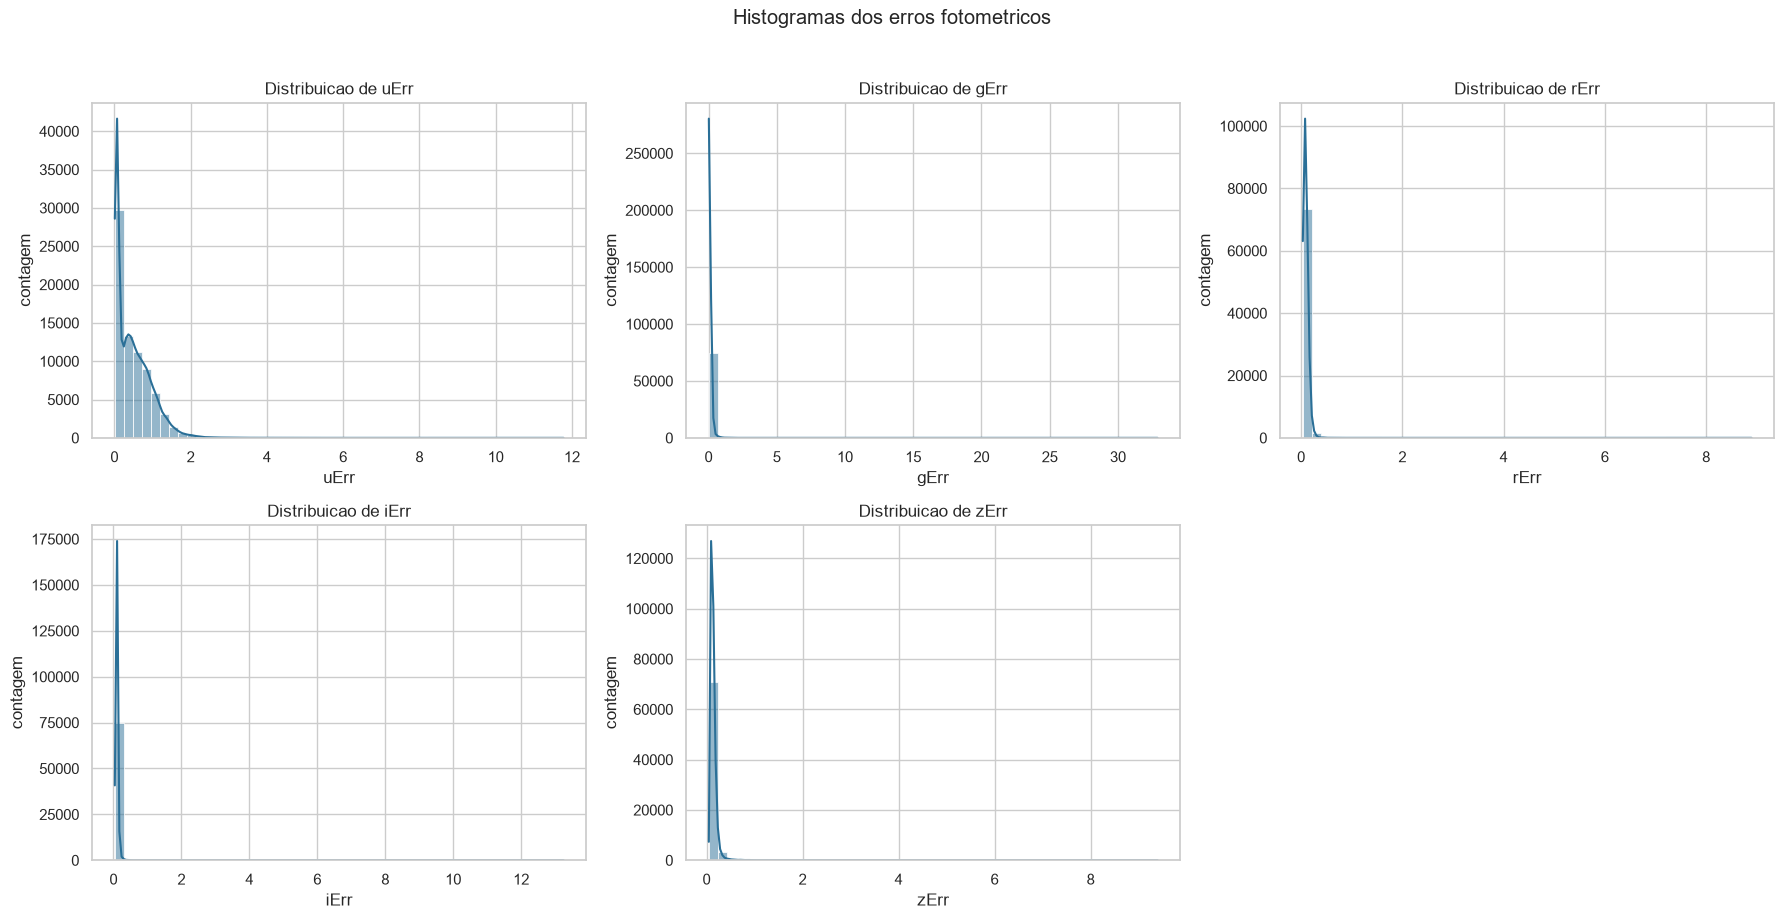

In [32]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()

for ax, col in zip(axes, err_cols):
    sns.histplot(df[col], bins=50, kde=True, ax=ax, color="#2a6f97")
    ax.set_title(f"Distribuicao de {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("contagem")

for ax in axes[len(err_cols):]:
    ax.axis("off")

plt.suptitle("Histogramas dos erros fotometricos", y=1.02)
plt.tight_layout()
plt.show()


### Zoom nas distribuicoes dos erros

Como as colunas de erro fotometrico possuem caudas longas, os histogramas em escala completa podem comprimir a regiao onde esta a maior parte dos objetos. Para enxergar melhor o corpo principal das distribuicoes, vamos aplicar um zoom visual ate o percentil 99 de cada banda. Esse filtro e usado apenas para visualizacao e nao remove dados do dataset.


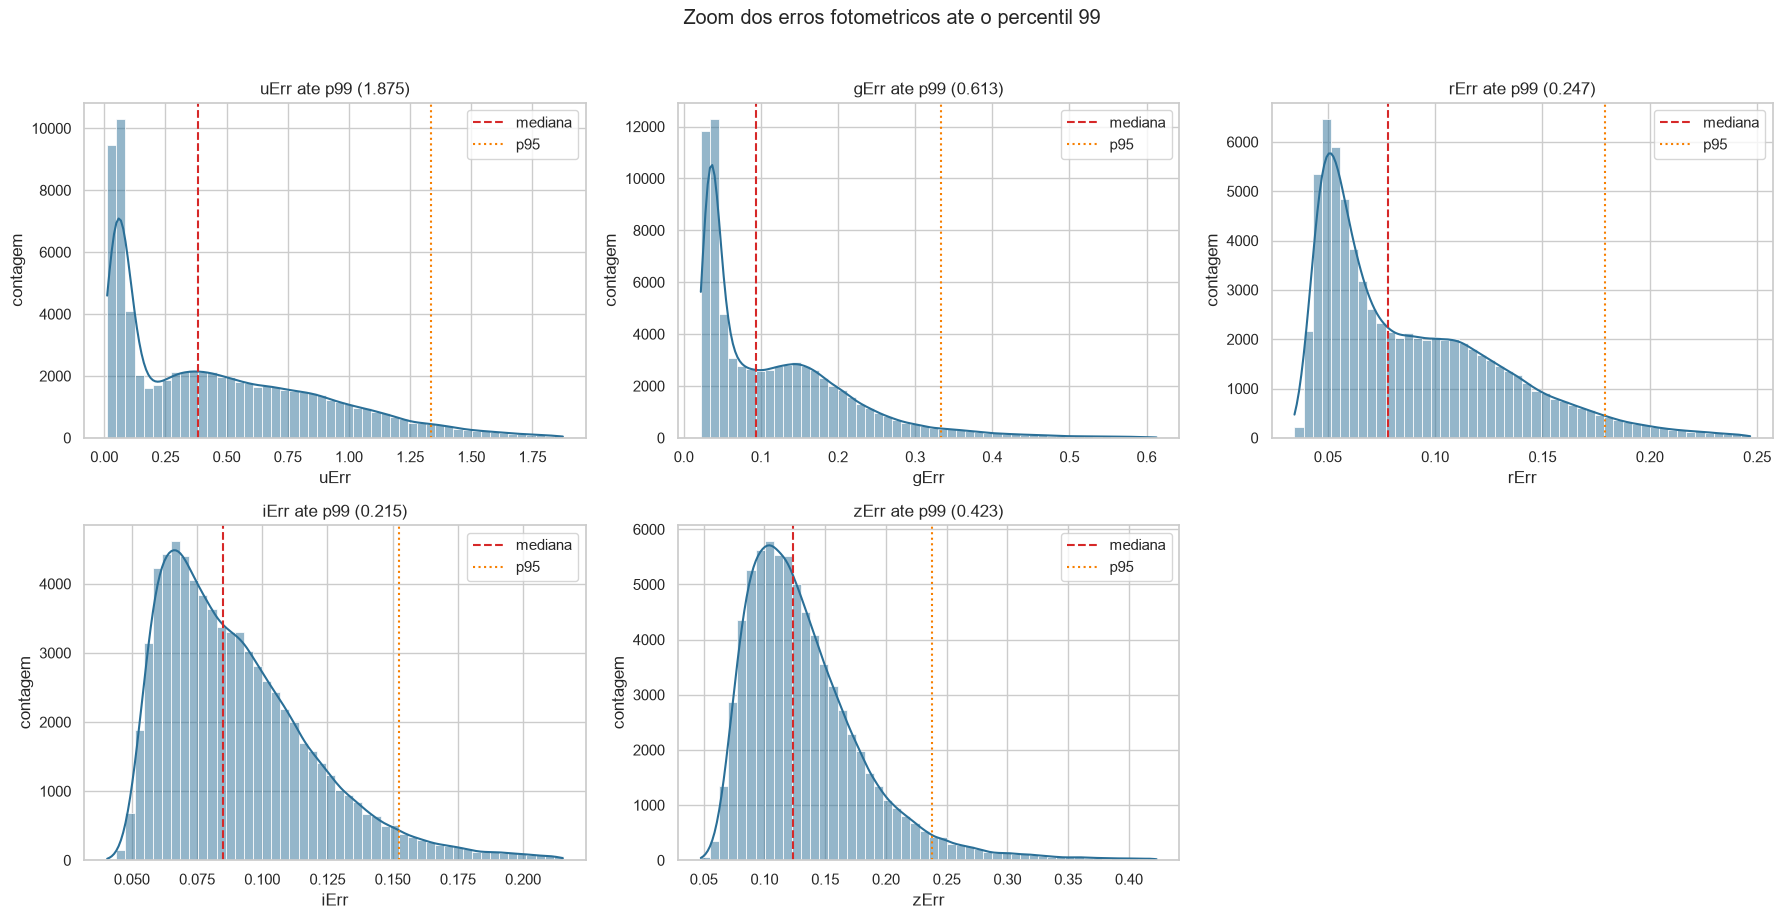

In [33]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()

for ax, col in zip(axes, err_cols):
    upper = df[col].quantile(0.99)
    zoom_values = df.loc[df[col] <= upper, col]

    sns.histplot(zoom_values, bins=50, kde=True, ax=ax, color="#2a6f97")
    ax.axvline(df[col].median(), color="#d62828", linestyle="--", linewidth=1.5, label="mediana")
    ax.axvline(df[col].quantile(0.95), color="#f77f00", linestyle=":", linewidth=1.5, label="p95")
    ax.set_title(f"{col} ate p99 ({upper:.3f})")
    ax.set_xlabel(col)
    ax.set_ylabel("contagem")
    ax.legend()

for ax in axes[len(err_cols):]:
    ax.axis("off")

plt.suptitle("Zoom dos erros fotometricos ate o percentil 99", y=1.02)
plt.tight_layout()
plt.show()


Com esse zoom, fica mais facil comparar a faixa tipica de erro entre as bandas. As linhas verticais marcam a mediana e o p95 de cada coluna, ajudando a separar a regiao comum da cauda alta. Se uma banda mantiver mediana e p95 bem maiores que as outras, isso sugere que suas incertezas podem carregar informacao relevante para o modelo. Agora vamos pro método Log1p, que pode ajudar a diminuir assimetrias positivas

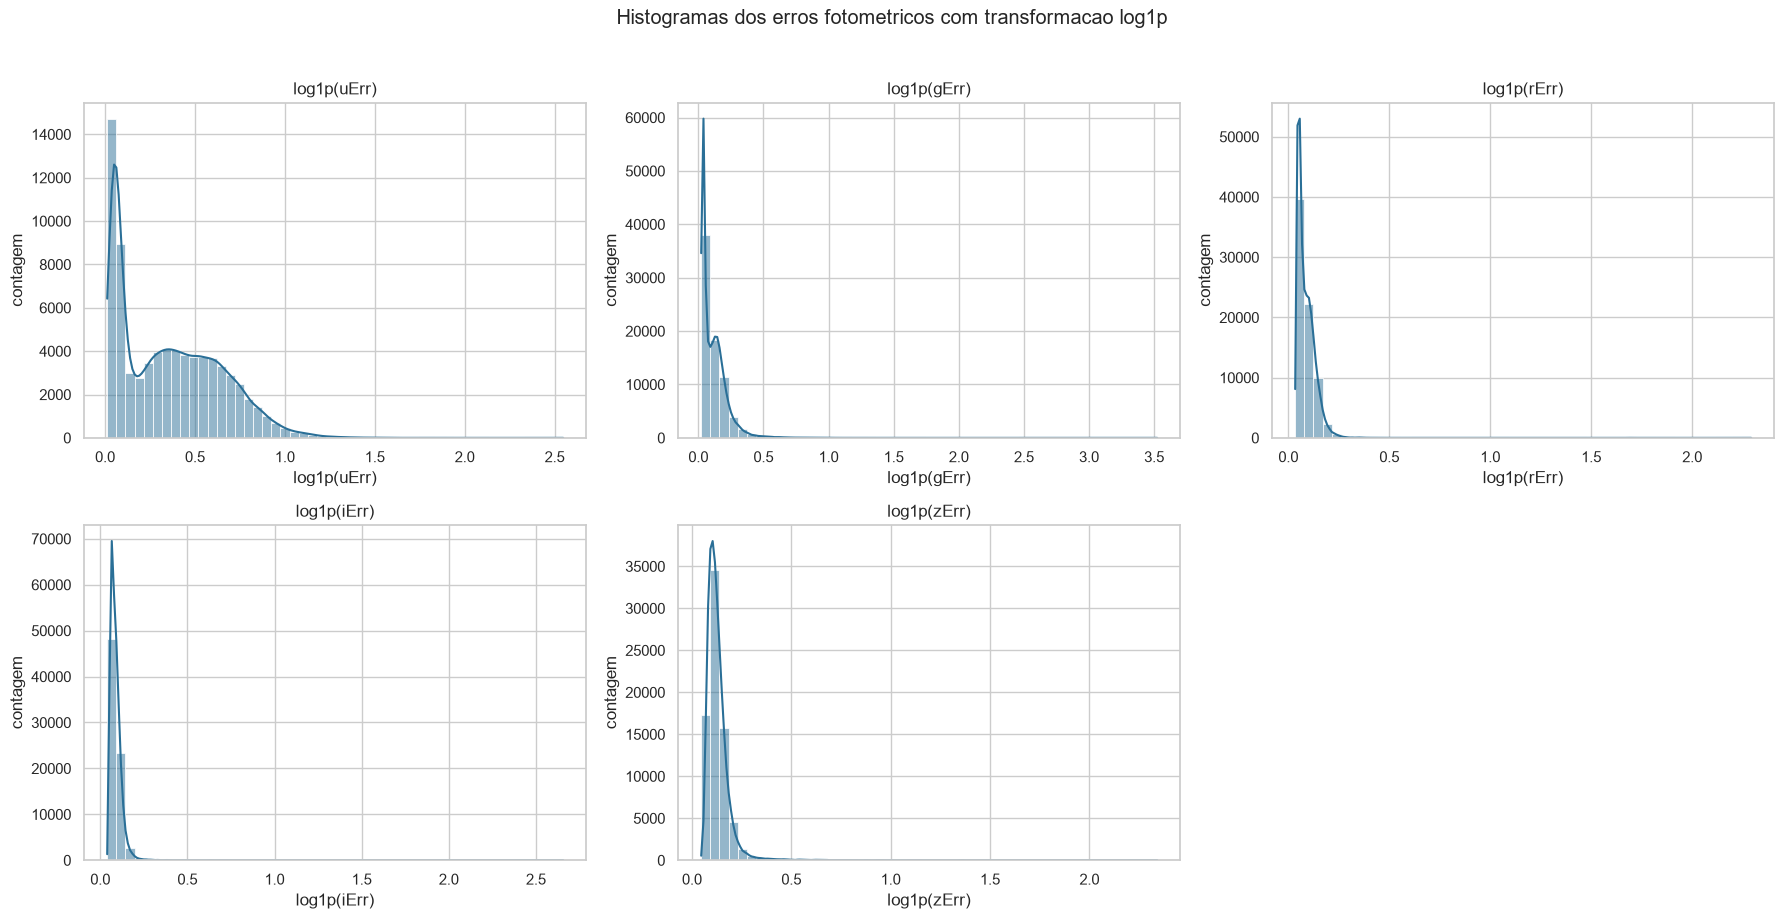

In [34]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()

for ax, col in zip(axes, err_cols):
    sns.histplot(np.log1p(df[col]), bins=50, kde=True, ax=ax, color="#2a6f97")
    ax.set_title(f"log1p({col})")
    ax.set_xlabel(f"log1p({col})")
    ax.set_ylabel("contagem")

for ax in axes[len(err_cols):]:
    ax.axis("off")

plt.suptitle("Histogramas dos erros fotometricos com transformacao log1p", y=1.02)
plt.tight_layout()
plt.show()


### Zoom nas distribuicoes dos erros apos `log1p`

Tambem aplicamos o zoom depois da transformacao `log1p`. O corte visual continua sendo feito ate o p99 da variavel original, mas o eixo exibido passa a ser `log1p(erro)`. Isso ajuda a comparar a regiao central das distribuicoes transformadas sem que os valores extremos dominem a escala.


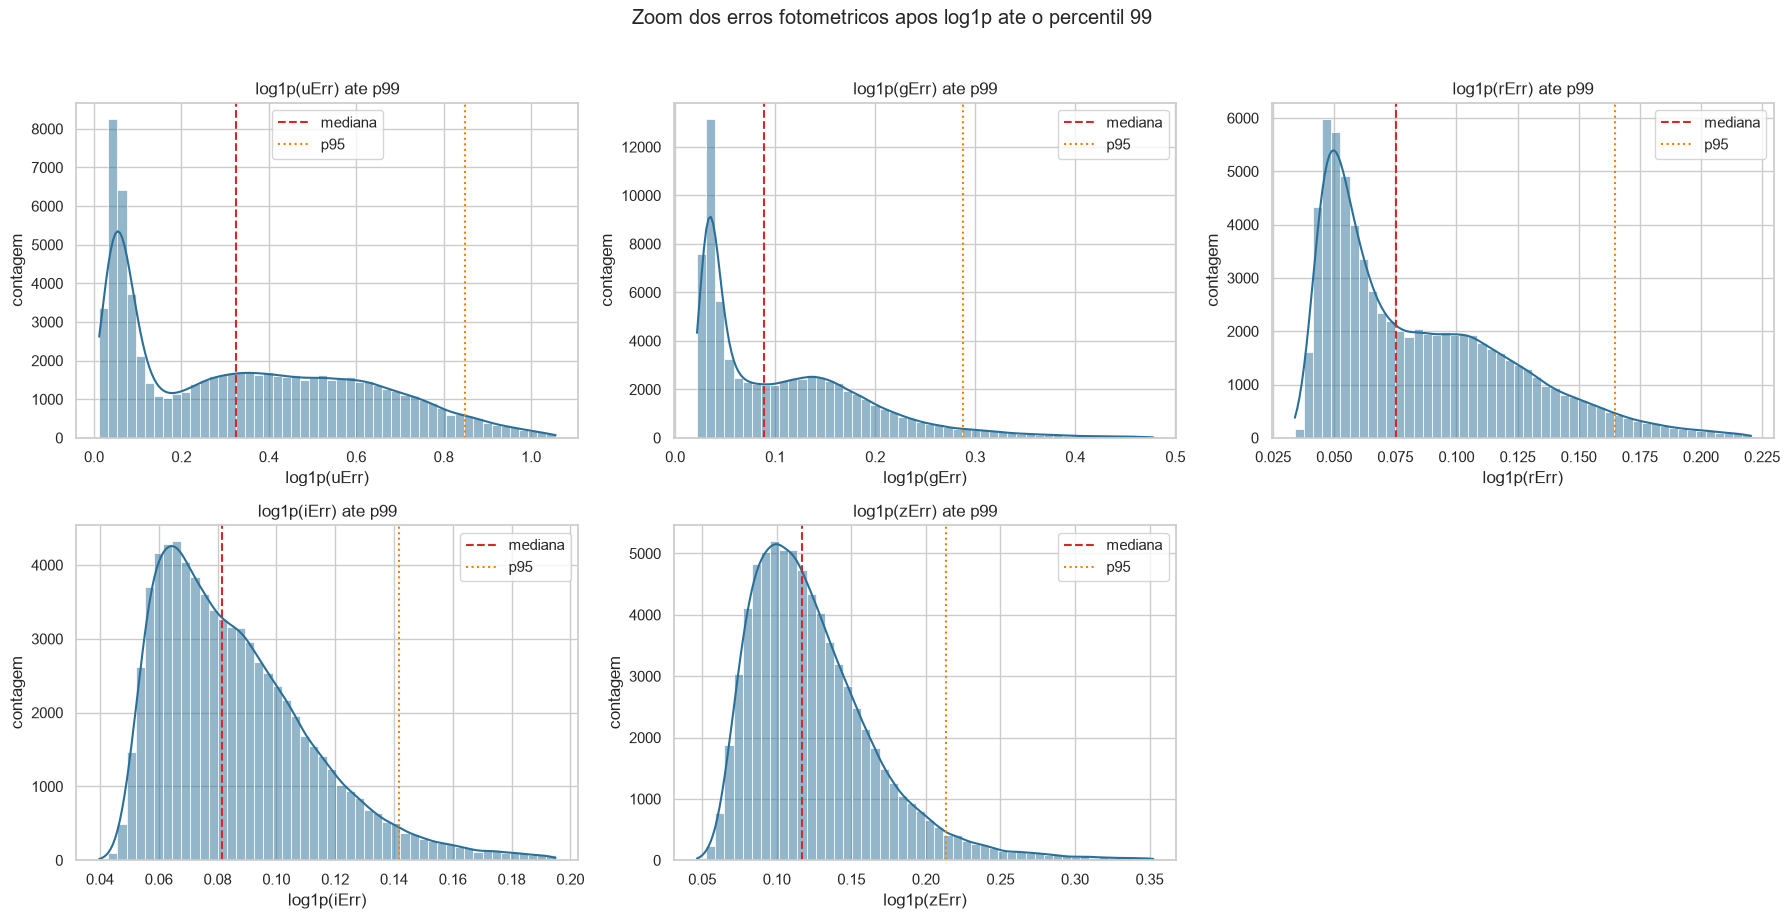

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()

for ax, col in zip(axes, err_cols):
    upper = df[col].quantile(0.99)
    zoom_values_log = np.log1p(df.loc[df[col] <= upper, col])
    median_log = np.log1p(df[col].median())
    p95_log = np.log1p(df[col].quantile(0.95))

    sns.histplot(zoom_values_log, bins=50, kde=True, ax=ax, color="#2a6f97")
    ax.axvline(median_log, color="#d62828", linestyle="--", linewidth=1.5, label="mediana")
    ax.axvline(p95_log, color="#f77f00", linestyle=":", linewidth=1.5, label="p95")
    ax.set_title(f"log1p({col}) ate p99")
    ax.set_xlabel(f"log1p({col})")
    ax.set_ylabel("contagem")
    ax.legend()

for ax in axes[len(err_cols):]:
    ax.axis("off")

plt.suptitle("Zoom dos erros fotometricos apos log1p ate o percentil 99", y=1.02)
plt.tight_layout()
plt.show()


Esses gráficos mostram a transformacao `log1p` nos erros das magnitudes. O objetivo principal é diminuir a assimetria a direita dessas features


## 6. Erros altos por banda e distribuicao do redshift

Nesta secao, vamos comparar diretamente a distribuicao de `redshift` entre objetos com diferentes niveis de erro fotometrico em cada banda. A pergunta central e: objetos com erro alto em uma banda possuem distribuicao de `redshift` diferente dos objetos com erro baixo?

Para isso, cada coluna de erro sera dividida em quatro grupos definidos por quantis da propria banda: `baixo`, `medio`, `alto` e `extremo`. Essa abordagem evita usar um mesmo limite absoluto para bandas que podem ter escalas de erro diferentes.


### 6.1 Criacao dos grupos de erro

A funcao abaixo cria grupos por quantis para uma coluna de erro. Os grupos sao definidos como: ate p25 para erro baixo, de p25 a p75 para erro medio, de p75 a p95 para erro alto, e acima de p95 para erro extremo.


In [ ]:
error_group_order = ["baixo", "medio", "alto", "extremo"]

def create_error_groups(df: pd.DataFrame, err_col: str) -> pd.Series:
    q25 = df[err_col].quantile(0.25)
    q75 = df[err_col].quantile(0.75)
    q95 = df[err_col].quantile(0.95)

    return pd.cut(
        df[err_col],
        bins=[-np.inf, q25, q75, q95, np.inf],
        labels=error_group_order,
        include_lowest=True,
    )


### 6.2 Estatisticas de redshift por grupo de erro

Para cada banda, criamos uma coluna temporaria de grupo de erro e calculamos estatisticas de `redshift` dentro de cada grupo. Essa tabela permite observar se a media, a mediana e os quantis de `redshift` mudam conforme a incerteza fotometrica aumenta.


In [ ]:
redshift_by_error_group_tables = []

for err_col in err_cols:
    temp = df[[target_col, err_col]].copy()
    temp["grupo_erro"] = create_error_groups(df, err_col)

    summary = (
        temp
        .groupby("grupo_erro", observed=False)[target_col]
        .agg(
            count="count",
            redshift_mean="mean",
            redshift_median="median",
            redshift_std="std",
            redshift_p25=lambda s: s.quantile(0.25),
            redshift_p75=lambda s: s.quantile(0.75),
            redshift_p95=lambda s: s.quantile(0.95),
        )
        .reindex(error_group_order)
        .reset_index()
    )
    summary.insert(0, "banda_erro", err_col)
    redshift_by_error_group_tables.append(summary)

redshift_by_error_group = pd.concat(redshift_by_error_group_tables, ignore_index=True)

display(redshift_by_error_group.style.format({
    "count": "{:,}",
    "redshift_mean": "{:.6f}",
    "redshift_median": "{:.6f}",
    "redshift_std": "{:.6f}",
    "redshift_p25": "{:.6f}",
    "redshift_p75": "{:.6f}",
    "redshift_p95": "{:.6f}",
}))


### 6.3 Boxplots de redshift por grupo de erro

Os boxplots abaixo mostram a distribuicao de `redshift` para os grupos `baixo`, `medio`, `alto` e `extremo` em cada banda de erro. Se os grupos de erro alto ou extremo apresentarem medianas, dispersoes ou caudas diferentes, isso sugere que as incertezas fotometricas podem carregar sinal relevante para o modelo.


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9), sharey=True)
axes = axes.flatten()

for ax, err_col in zip(axes, err_cols):
    temp = df[[target_col, err_col]].copy()
    temp["grupo_erro"] = create_error_groups(df, err_col)

    sns.boxplot(
        data=temp,
        x="grupo_erro",
        y=target_col,
        order=error_group_order,
        ax=ax,
        color="#89c2d9",
    )
    ax.set_title(f"{target_col} por grupo de {err_col}")
    ax.set_xlabel("grupo de erro")
    ax.set_ylabel(target_col)

for ax in axes[len(err_cols):]:
    ax.axis("off")

plt.suptitle("Distribuicao de redshift por grupos de erro fotometrico", y=1.02)
plt.tight_layout()
plt.show()


### Leitura esperada

A comparacao deve procurar mudancas monotonicamente associadas ao nivel de erro. Por exemplo, se o grupo `extremo` tiver redshift medio ou mediano maior que o grupo `baixo`, isso pode indicar que objetos em redshifts mais altos sao medidos com maior incerteza em determinada banda.

Se as distribuicoes forem muito parecidas entre grupos, a coluna de erro ainda pode ajudar modelos nao lineares em interacoes com magnitudes e cores, mas a evidencia univariada sera mais fraca. Essa analise nao decide sozinha se os erros devem entrar no modelo; ela orienta os experimentos de modelagem com e sem incertezas fotometricas como features.
